<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Delos_ReyesClustering_Methods_Exercises_ANSWERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Methods Exercises

## Introduction

We will be using the wine quality data set for these exercises. This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data`.

We will be using the chemical properties (i.e. everything but quality and color) to cluster the wine. Though this is unsupervised learning, it can be fun to see how our clustering results map onto color and quality.

In [ ]:
from __future__ import print_function
import os
data_path = ['..', '..', 'data']

## Question 1

* Import the data and examine the features.
* Note which are continuous, categorical, and boolean.
* How many entries are there for the two colors and range of qualities?
* Make a histogram plot of the quality for each of the wine colors.

In [ ]:
import pandas as pd

# Import the data
filepath = ('/content/Wine_Quality_Data.csv')
data = pd.read_csv(filepath)

data.head(4).T

,0,1,2,3
fixed_acidity,7.4,7.8,7.8,11.2
volatile_acidity,0.7,0.88,0.76,0.28
citric_acid,0.0,0.0,0.04,0.56
residual_sugar,1.9,2.6,2.3,1.9
chlorides,0.076,0.098,0.092,0.075
free_sulfur_dioxide,11.0,25.0,15.0,17.0
total_sulfur_dioxide,34.0,67.0,54.0,60.0
density,0.9978,0.9968,0.997,0.998
pH,3.51,3.2,3.26,3.16
sulphates,0.56,0.68,0.65,0.58


In [ ]:
data.shape

(6497, 13)

The data types for each entry. The implementation of K-means in Scikit-learn is designed only to work with continuous data (even though it is sometimes used with categorical or boolean types). Fortunately, all the columns we will be using (everything except quality and color) are continuous.

In [ ]:
data.dtypes

,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64


The number of entries for each wine color.

In [ ]:
data.color.value_counts()

,count
color,
white,4898
red,1599


The distribution of quality values.

In [ ]:
data.quality.value_counts().sort_index()

,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


Now for the histogram.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

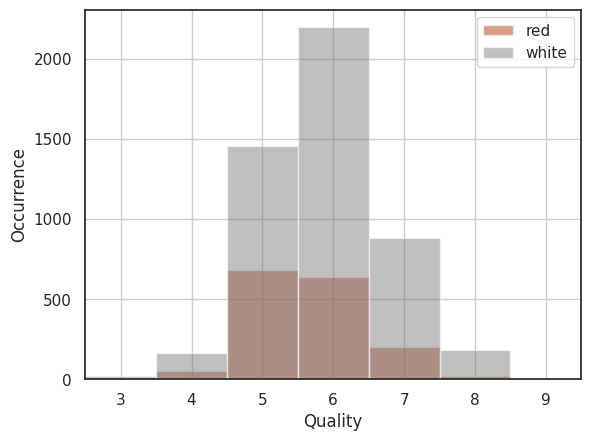

In [ ]:
# seaborn styles
sns.set_context('notebook')
sns.set_style('white')
sns.set_palette('dark')

# custom colors
red = sns.color_palette()[1]
white = 'gray'

# set bins for histogram
bin_range = np.array([3, 4, 5, 6, 7, 8, 9])

# plot histogram of quality counts for red and white wines
ax = plt.axes()
for color, plot_color in zip(['red', 'white'], [red, white]):
    q_data = data.loc[data.color==color, 'quality']
    q_data.hist(bins=bin_range,
                alpha=0.5, ax=ax,
                color=plot_color, label=color)


ax.legend()
ax.set(xlabel='Quality', ylabel='Occurrence')

# force tick labels to be in middle of region
ax.set_xlim(3,10)
ax.set_xticks(bin_range+0.5)
ax.set_xticklabels(bin_range);
ax.grid('off')


## Question 2

* Example the correlation and skew of the relevant variables--everything except color and quality.
* Perform any appropriate feature transformations and/or scaling.
* Examine the pairwise distribution of the variables with pairplots to verify scaling and normalization efforts.


In [ ]:
float_columns = [x for x in data.columns if x not in ['color', 'quality']]

# The correlation matrix
corr_mat = data[float_columns].corr()

# Strip out the diagonal values for the next step
for x in range(len(float_columns)):
    corr_mat.iloc[x,x] = 0.0

corr_mat

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,0.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile_acidity,0.219008,0.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric_acid,0.324436,-0.377981,0.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual_sugar,-0.111981,-0.196011,0.142451,0.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,0.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free_sulfur_dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,0.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total_sulfur_dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,0.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,0.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,0.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,0.000000,-0.003029


In [ ]:
# Pairwise maximal correlations
corr_mat.abs().idxmax()

,0
fixed_acidity,density
volatile_acidity,total_sulfur_dioxide
citric_acid,volatile_acidity
residual_sugar,density
chlorides,sulphates
free_sulfur_dioxide,total_sulfur_dioxide
total_sulfur_dioxide,free_sulfur_dioxide
density,alcohol
pH,citric_acid
sulphates,chlorides


And an examination of the skew values in anticipation of transformations.

In [ ]:
skew_columns = (data[float_columns]
                .skew()
                .sort_values(ascending=False))

skew_columns = skew_columns.loc[skew_columns > 0.75]
skew_columns

,0
chlorides,5.399828
sulphates,1.797270
fixed_acidity,1.723290
volatile_acidity,1.495097
residual_sugar,1.435404
free_sulfur_dioxide,1.220066


In [ ]:
# Perform log transform on skewed columns
for col in skew_columns.index.tolist():
    data[col] = np.log1p(data[col])


Perform feature scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
data[float_columns] = sc.fit_transform(data[float_columns])

data.head(4)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,0.229509,2.135767,-2.192833,-0.815173,0.624554,-1.193601,-1.446359,1.034993,1.813090,0.250355,-0.915464,5,red
1,0.550261,3.012817,-2.192833,-0.498175,1.281999,-0.013944,-0.862469,0.701486,-0.115073,1.059213,-0.580068,5,red
2,0.550261,2.438032,-1.917553,-0.625740,1.104012,-0.754684,-1.092486,0.768188,0.258120,0.862549,-0.580068,5,red
3,2.802728,-0.337109,1.661085,-0.815173,0.594352,-0.574982,-0.986324,1.101694,-0.363868,0.389396,-0.580068,6,red


Finally, the pairplot of the transformed and scaled features.

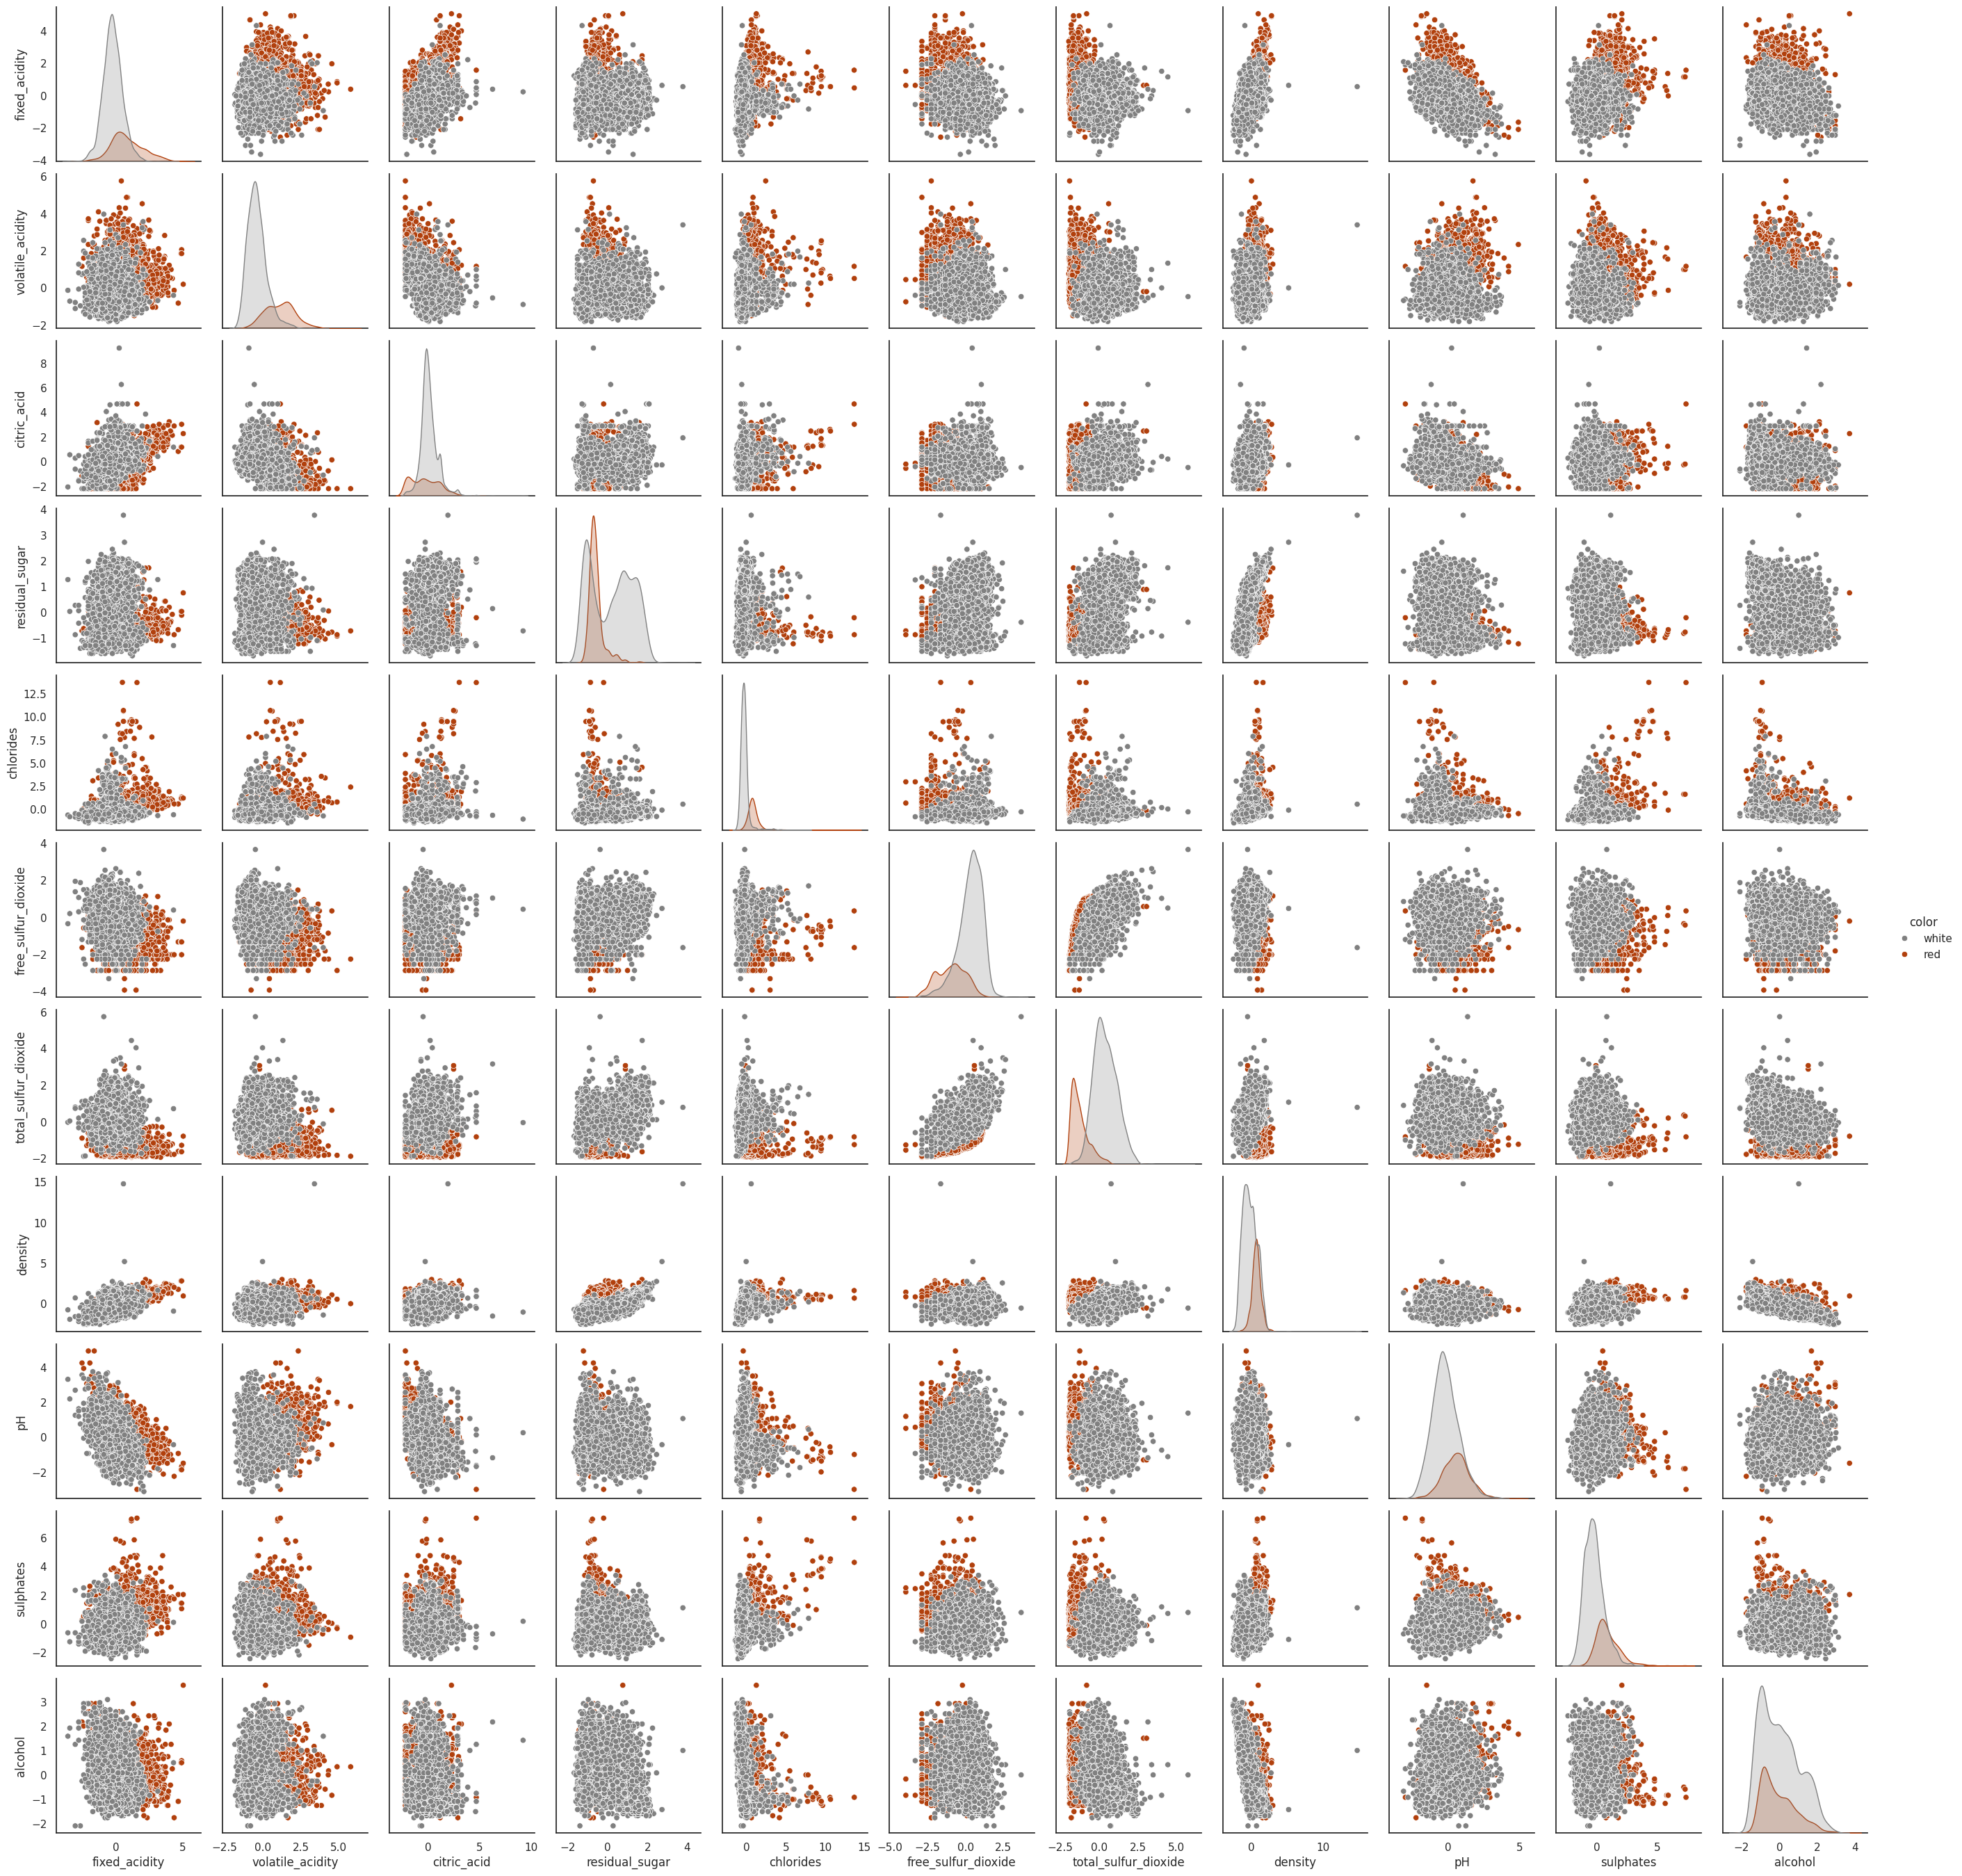

In [ ]:
sns.set_context('notebook')
sns.pairplot(data[float_columns + ['color']],
             hue='color',
             hue_order=['white', 'red'],
             palette={'red':red, 'white':'gray'});

## Question 3

* Fit a K-means clustering model with two clusters.
* Examine the clusters by wine color.

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, random_state=42)
km = km.fit(data[float_columns])

data['kmeans'] = km.predict(data[float_columns])

In [ ]:
(data[['color','kmeans']]
 .groupby(['color','kmeans'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))

number
color kmeans        
red   0         1576
      1           23
white 0           87
      1         4811

# Compute for Inertia of  2 clusters


In [ ]:
#compute for the intertia of 2 clusters
inertia = km.inertia_
inertia

55455.98111267371

#Use the elbow method to find the best(optimal) value of K. Check the inertia


Clusters: 1, Inertia: 71467.0000000004, Distortion: 3.141315202608529
Clusters: 2, Inertia: 55455.98111267371, Distortion: 2.7630309753564095
Clusters: 3, Inertia: 45199.88406600541, Distortion: 2.4513000563727796
Clusters: 4, Inertia: 42548.109479927385, Distortion: 2.3754435301057453
Clusters: 5, Inertia: 38232.26978015472, Distortion: 2.258615625269573
Clusters: 6, Inertia: 36369.05274319205, Distortion: 2.200718881434912
Clusters: 7, Inertia: 35089.4187648506, Distortion: 2.153197847856045
Clusters: 8, Inertia: 33923.53496115267, Distortion: 2.11616058752751
Clusters: 9, Inertia: 31996.422967252947, Distortion: 2.0877080042663207
Clusters: 10, Inertia: 31070.250442294287, Distortion: 2.0533380567953756


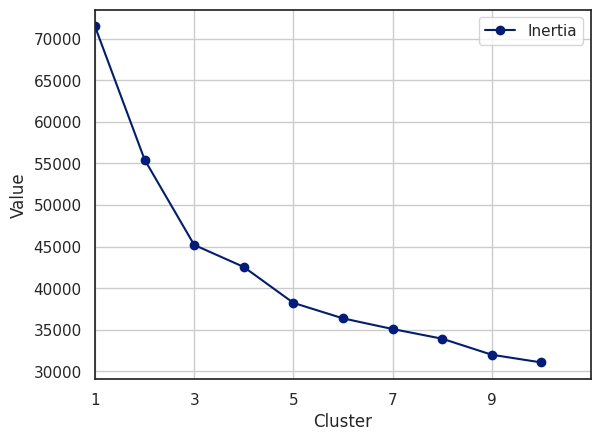

In [ ]:
from scipy.spatial.distance import cdist

km_list = list()

for clust in range(1, 11):
    km = KMeans(n_clusters=clust, random_state=42)
    km = km.fit(data[float_columns])

    # Calculate distortion
    distortion = sum(np.min(cdist(data[float_columns], km.cluster_centers_, 'euclidean'), axis=1)) / data[float_columns].shape[0]

    km_list.append(pd.Series({'clusters': clust,
                              'inertia': km.inertia_,
                              'distortion': distortion,  # Add distortion to the Series
                              'model': km}))

# Display inertia and distortion values
for km_model in km_list:
    print(f"Clusters: {km_model['clusters']}, Inertia: {km_model['inertia']}, Distortion: {km_model['distortion']}")

# Plot cluster number vs inertia and distortion
plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters', 'inertia']]  # Include distortion in plot data (, 'distortion')
             .set_index('clusters'))

ax = plot_data.plot(marker='o', ls='-')
ax.set_xticks(range(0, 10,2))
ax.set_xlim(0, 10)
ax.set(xlabel='Cluster', ylabel='Value')  # Update ylabel to 'Value'
plt.legend(['Inertia', 'Distortion'])  # Add legend to distinguish lines
plt.grid()
plt.show()

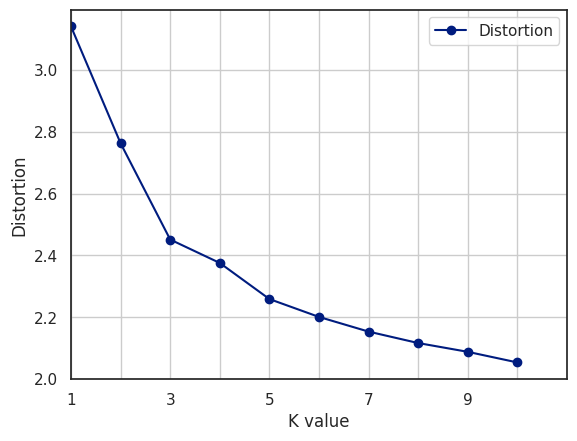

In [ ]:
plot_data = (pd.concat(km_list, axis=1)
             .T
             [['distortion', 'clusters']]  # Include distortion in plot data (, 'distortion')
             .set_index('clusters'))

ax = plot_data.plot(marker='o', ls='-')
ax.set_xticks(range(0, 10))
ax.set_xlim(0, 10)
ax.set(xlabel='K value', ylabel='Distortion')
plt.legend(['Distortion'])  # Add legend to distinguish lines
plt.grid()
plt.show()

## Question 4

* Now fit K-Means models with cluster values ranging from 1 to 20.
* For each model, store the number of clusters and the inertia value.
* Plot cluster number vs inertia. Does there appear to be an ideal cluster number?

In [ ]:
# Create and fit a range of models
km_list = list()

for clust in range(1,21):
    km = KMeans(n_clusters=clust, random_state=42)
    km = km.fit(data[float_columns])

    km_list.append(pd.Series({'clusters': clust,
                              'inertia': km.inertia_,
                              'model': km}))

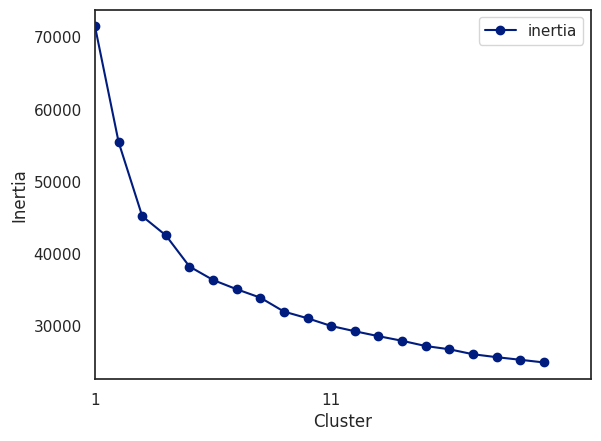

In [ ]:
plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters','inertia']]
             .set_index('clusters'))

ax = plot_data.plot(marker='o',ls='-')
ax.set_xticks(range(0,21,2))
ax.set_xlim(0,21)
ax.set(xlabel='Cluster', ylabel='Inertia');

In [ ]:
#compute for the intertia of 2 clusters
inertia = km.inertia_
inertia

24956.146245046224

## Question 5

* Fit an agglomerative clustering model with two clusters.
* Compare the results to those obtained by K-means with regards to wine color.
* Visualize the dendrogram produced by agglomerative clustering. *Hint:* SciPy has a module called [`cluster.hierarchy`](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html#module-scipy.cluster.hierarchy) that contains the `linkage` and `dendrogram` functions required to create the linkage map and plot the resulting dendrogram.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

ag = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_full_tree=True)
ag = ag.fit(data[float_columns])
data['agglom'] = ag.fit_predict(data[float_columns])

Note that cluster assignment is arbitrary, the respective primary cluster numbers for red and white may not be identical to the ones below and also may not be the same for both K-means and agglomerative clustering.

In [ ]:
(data[['color','agglom','kmeans']]
 .groupby(['color','agglom','kmeans'])
 .size()
 .to_frame()
 .rename(columns={0:'number'}))

number
color agglom kmeans        
red   0      0           13
             1           18
      1      0         1563
             1            5
white 0      0           38
             1         4717
      1      0           49
             1           94

#Compute the inertia  for agglomerative clusterring

In [ ]:
from scipy.cluster.hierarchy import cophenet,linkage
from scipy.spatial.distance import pdist

# Calculate linkage matrix
Z = linkage(data[float_columns], 'ward')

# Calculate cophenet score
c, coph_dists = cophenet(Z, pdist(data[float_columns]))
print(f"Inertia proxy (cophenet score): {c}")

Inertia proxy (cophenet score): 0.5532842562983665


In [ ]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate the silhouette score
silhouette = silhouette_score(data[float_columns], ag.labels_)
print(f"Silhouette Score: {silhouette}")

# Calculate the Davies-Bouldin index
davies_bouldin = davies_bouldin_score(data[float_columns], ag.labels_)
print(f"Davies-Bouldin Index: {davies_bouldin}")

Silhouette Score: 0.2736426051226361
Davies-Bouldin Index: 1.6535899022145746


#Use silhoutte Method to find the best cluster and use it to create the new agglomerative clustering model.Compute the inertia

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# Range of clusters to evaluate
cluster_range = range(2, 11)  # Evaluate clusters from 2 to 10

best_cluster = None
best_silhouette = -1

# Iterate through cluster numbers and calculate silhouette scores
for n_clusters in cluster_range:
    ag = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = ag.fit_predict(data[float_columns])  # Use your preprocessed data
    silhouette_avg = silhouette_score(data[float_columns], cluster_labels)

    # Update best cluster if silhouette score is better
    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_cluster = n_clusters

print(f"Optimal number of clusters: {best_cluster}")
print(f"Best Silhouette Score: {best_silhouette}")


Optimal number of clusters: 2
Best Silhouette Score: 0.2736426051226361


In [ ]:
# Create the model with the optimal cluster number
optimal_ag = AgglomerativeClustering(n_clusters=best_cluster, linkage='ward')

# Fit the model to your data
optimal_ag.fit(data[float_columns])

# Get cluster labels
data['agglom_optimal'] = optimal_ag.labels_  # Store in a new column

In [ ]:
from scipy.cluster.hierarchy import cophenet,linkage
from scipy.spatial.distance import pdist

# Calculate linkage matrix
Z = linkage(data[float_columns], 'ward')

# Calculate cophenet score
c, coph_dists = cophenet(Z, pdist(data[float_columns]))
print(f"Inertia proxy (cophenet score): {c}")

Inertia proxy (cophenet score): 0.5532842562983665


#Use Gap Statistic Method to find the best cluster and use it to create the new Gap Statistic clustering model.Compute the inertia

In this code below, I run the python file here since the gap_statistic library is not running  in Google Colab

In [ ]:
# -*- coding: utf-8 -*-

import warnings
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from collections import namedtuple
from multiprocessing import cpu_count
from typing import Union, Iterable, Callable, Generator
from scipy.cluster.vq import kmeans2

try:
    import matplotlib.pyplot as plt

    MATPLOTLIB_FOUND = True
except ImportError:
    MATPLOTLIB_FOUND = False
    warnings.warn("matplotlib not installed; results plotting is disabled.")
try:
    from joblib import Parallel, delayed
except ImportError:
    Parallel, delayed = None, None
    warnings.warn(
        "joblib not installed, will be unavailable as a backend for parallel processing."
    )


GapCalcResult = namedtuple(
    "GapCalcResult", "gap_value n_clusters ref_dispersion_std sdk sk gap_star sk_star"
)


class OptimalK:
    """
    Obtain the optimal number of clusters a dataset should have using the gap statistic.
        Tibshirani, Walther, Hastie
        http://www.web.stanford.edu/~hastie/Papers/gap.pdf

    Example:
    >>> from sklearn.datasets.samples_generator import make_blobs
    >>> from gap_statistic import OptimalK
    >>> X, y = make_blobs(n_samples=int(1e5), n_features=2, centers=3, random_state=100)
    >>> optimalK = OptimalK(parallel_backend='joblib')
    >>> optimalK(X, cluster_array=[1,2,3,4,5])
    3
    """

    gap_df = None

    def __init__(
        self,
        n_jobs: int = -1,
        parallel_backend: str = "joblib",
        clusterer: Callable = None,
        clusterer_kwargs: dict = None,
        n_iter: int = 10,
        random_state: int = None
    ) -> None:
        """
        Construct OptimalK to use n_jobs (multiprocessing using joblib, multiprocessing, or single core.
        if parallel_backend == 'rust' it will use all cores.

        :param n_jobs:
        :param parallel_backend:
        :param clusterer:
        :param clusterer_kwargs:
        :param n_iter int: only valid for 'rust' backend, iterations for Kmeans
        :param random_state int: initialize RNG used to create random reference set
        """
        if clusterer is not None and parallel_backend == "rust":
            raise ValueError(
                "Cannot use 'rust' backend with a user defined clustering function, only KMeans"
                " is supported on the rust implementation"
            )
        self.parallel_backend = (
            parallel_backend
            if parallel_backend in ["joblib", "multiprocessing", "rust"]
            else None
        )
        self.n_iter = n_iter
        self.n_jobs = n_jobs if 1 <= n_jobs <= cpu_count() else cpu_count()  # type: int
        self.n_jobs = 1 if parallel_backend is None else self.n_jobs
        self.clusterer = clusterer if clusterer is not None else kmeans2
        self.clusterer_kwargs = (
            clusterer_kwargs or dict()
            if clusterer is not None
            else dict(iter=10, minit="points")
        )
        self._rs = np.random.RandomState(seed=random_state)

    def __call__(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        n_refs: int = 3,
        cluster_array: Iterable[int] = (),
    ):
        """
        Calculates KMeans optimal K using Gap Statistic from Tibshirani, Walther, Hastie
        http://www.web.stanford.edu/~hastie/Papers/gap.pdf
        :param X - pandas dataframe or numpy array of data points of shape (n_samples, n_features)
        :param n_refs - int: Number of random reference data sets used as inertia reference to actual data.
        :param cluster_array - 1d iterable of integers; each representing n_clusters to try on the data.
        """

        # Convert the 1d array of n_clusters to try into an array
        # Raise error if values are less than 1 or larger than the unique sample in the set.
        cluster_array = np.array([x for x in cluster_array]).astype(int)
        if np.where(cluster_array < 1)[0].shape[0]:
            raise ValueError(
                "cluster_array contains values less than 1: {}".format(
                    cluster_array[np.where(cluster_array < 1)[0]]
                )
            )
        if cluster_array.shape[0] > X.shape[0]:
            raise ValueError(
                "The number of suggested clusters to try ({}) is larger than samples in dataset. ({})".format(
                    cluster_array.shape[0], X.shape[0]
                )
            )
        if not cluster_array.shape[0]:
            raise ValueError("The supplied cluster_array has no values.")

        # Array of resulting gaps.
        gap_df = pd.DataFrame({"n_clusters": [], "gap_value": []})

        # Define the compute engine; all methods take identical args and are generators.
        if self.parallel_backend == "joblib":
            engine = self._process_with_joblib
        elif self.parallel_backend == "multiprocessing":
            engine = self._process_with_multiprocessing
        elif self.parallel_backend == "rust":
            engine = self._process_with_rust
        else:
            engine = self._process_non_parallel

        # Calculate the gaps for each cluster count.
        for gap_calc_result in engine(X, n_refs, cluster_array):
            # Assign this loop's gap statistic to gaps
            gap_df = pd.concat(
                [
                    gap_df,
                    pd.DataFrame(
                        {
                            "n_clusters": [gap_calc_result.n_clusters],
                            "gap_value": [gap_calc_result.gap_value],
                            "ref_dispersion_std": [gap_calc_result.ref_dispersion_std],
                            "sdk": [gap_calc_result.sdk],
                            "sk": [gap_calc_result.sk],
                            "gap*": [gap_calc_result.gap_star],
                            "sk*": [gap_calc_result.sk_star],
                        }
                    ),
                ]
            )
            gap_df["gap_k+1"] = gap_df["gap_value"].shift(-1)
            gap_df["gap*_k+1"] = gap_df["gap*"].shift(-1)
            gap_df["sk+1"] = gap_df["sk"].shift(-1)
            gap_df["sk*+1"] = gap_df["sk*"].shift(-1)
            gap_df["diff"] = gap_df["gap_value"] - gap_df["gap_k+1"] + gap_df["sk+1"]
            gap_df["diff*"] = gap_df["gap*"] - gap_df["gap*_k+1"] + gap_df["sk*+1"]

        # drop auxilariy columns
        gap_df.drop(
            labels=["sdk", "gap_k+1", "gap*_k+1", "sk+1", "sk*+1"],
            axis=1,
            inplace=True,
            errors="ignore",
        )

        self.gap_df = gap_df.sort_values(by="n_clusters", ascending=True).reset_index(
            drop=True
        )
        self.n_clusters = int(
            self.gap_df.loc[np.argmax(self.gap_df.gap_value.values)].n_clusters
        )
        return self.n_clusters

    def plot_results(self):
        """
        Plots the results of the last run optimal K search procedure.
        Four plots are printed:
        (1) A plot of the Gap value - as defined in the original Tibshirani et
        al paper - versus n, the number of clusters.
        (2) A plot of diff versus n, the number of clusters, where diff =
        Gap(k) - Gap(k+1) + s_{k+1}. The original Tibshirani et al paper
        recommends choosing the smallest k such that this measure is positive.
        (3) A plot of the Gap* value - a variant of the Gap statistic suggested
        in "A comparison of Gap statistic definitions with and with-out
        logarithm function" [https://core.ac.uk/download/pdf/12172514.pdf],
        which simply removes the logarithm operation from the Gap calculation -
        versus n, the number of clusters.
        (4) A plot of the diff* value versus n, the number of clusters. diff*
        corresponds to the aforementioned diff value for the case of Gap*.
        """
        if not MATPLOTLIB_FOUND:
            print("matplotlib not installed; results plotting is disabled.")
            return
        if not hasattr(self, "gap_df") or self.gap_df is None:
            print("No results to print. OptimalK not called yet.")
            return

        # Gap values plot
        plt.plot(self.gap_df.n_clusters, self.gap_df.gap_value, linewidth=3)
        plt.scatter(
            self.gap_df[self.gap_df.n_clusters == self.n_clusters].n_clusters,
            self.gap_df[self.gap_df.n_clusters == self.n_clusters].gap_value,
            s=250,
            c="r",
        )
        plt.grid(True)
        plt.xlabel("Cluster Count")
        plt.ylabel("Gap Value")
        plt.title("Gap Values by Cluster Count")
        plt.show()

        # diff plot
        plt.plot(self.gap_df.n_clusters, self.gap_df["diff"], linewidth=3)
        plt.grid(True)
        plt.xlabel("Cluster Count")
        plt.ylabel("Diff Value")
        plt.title("Diff Values by Cluster Count")
        plt.show()

        # Gap* plot
        max_ix = self.gap_df[self.gap_df["gap*"] == self.gap_df["gap*"].max()].index[0]
        plt.plot(self.gap_df.n_clusters, self.gap_df["gap*"], linewidth=3)
        plt.scatter(
            self.gap_df.loc[max_ix]["n_clusters"],
            self.gap_df.loc[max_ix]["gap*"],
            s=250,
            c="r",
        )
        plt.grid(True)
        plt.xlabel("Cluster Count")
        plt.ylabel("Gap* Value")
        plt.title("Gap* Values by Cluster Count")
        plt.show()

        # diff* plot
        plt.plot(self.gap_df.n_clusters, self.gap_df["diff*"], linewidth=3)
        plt.grid(True)
        plt.xlabel("Cluster Count")
        plt.ylabel("Diff* Value")
        plt.title("Diff* Values by Cluster Count")
        plt.show()

    @staticmethod
    def _calculate_dispersion(
        X: Union[pd.DataFrame, np.ndarray], labels: np.ndarray, centroids: np.ndarray
    ) -> float:
        """
        Calculate the dispersion between actual points and their assigned centroids
        """
        disp = np.sum(
            np.sum(
                [np.abs(inst - centroids[label]) ** 2 for inst, label in zip(X, labels)]
            )
        )
        return disp

    def _calculate_gap(
        self, X: Union[pd.DataFrame, np.ndarray], n_refs: int, n_clusters: int
    ) -> GapCalcResult:
        """
        Calculate the gap value of the given data, n_refs, and number of clusters.
        Return the resulting gap value and n_clusters
        """
        # Holder for reference dispersion results
        ref_dispersions = np.zeros(n_refs)

        # Compute the range of each feature
        X = np.asarray(X)
        a, b = X.min(axis=0, keepdims=True), X.max(axis=0, keepdims=True)

        # For n_references, generate random sample and perform kmeans getting resulting dispersion of each loop
        for i in range(n_refs):
            # Create new random reference set uniformly over the range of each feature
            random_data = self._rs.random_sample(size=X.shape) * (b - a) + a

            # Fit to it, getting the centroids and labels, and add to accumulated reference dispersions array.
            centroids, labels = self.clusterer(
                random_data, n_clusters, **self.clusterer_kwargs
            )  # type: Tuple[np.ndarray, np.ndarray]
            dispersion = self._calculate_dispersion(
                X=random_data, labels=labels, centroids=centroids
            )
            ref_dispersions[i] = dispersion

        # Fit cluster to original data and create dispersion calc.
        centroids, labels = self.clusterer(
            X, n_clusters, **self.clusterer_kwargs
        )  # type: Tuple[np.ndarray, np.ndarray]
        dispersion = self._calculate_dispersion(X=X, labels=labels, centroids=centroids)

        # Calculate gap statistic
        ref_log_dispersion = np.mean(np.log(ref_dispersions))
        log_dispersion = np.log(dispersion)
        gap_value = ref_log_dispersion - log_dispersion
        # compute standard deviation
        sdk = np.sqrt(np.mean((np.log(ref_dispersions) - ref_log_dispersion) ** 2.0))
        sk = np.sqrt(1.0 + 1.0 / n_refs) * sdk

        # Calculate Gap* statistic
        # by "A comparison of Gap statistic definitions with and
        # with-out logarithm function"
        # https://core.ac.uk/download/pdf/12172514.pdf
        gap_star = np.mean(ref_dispersions) - dispersion
        sdk_star = np.sqrt(np.mean((ref_dispersions - dispersion) ** 2.0))
        sk_star = np.sqrt(1.0 + 1.0 / n_refs) * sdk_star

        return GapCalcResult(
            gap_value,
            int(n_clusters),
            ref_dispersions.std(),
            sdk,
            sk,
            gap_star,
            sk_star,
        )

    def _process_with_rust(
        self, X: Union[pd.DataFrame, np.ndarray], n_refs: int, cluster_array: np.ndarray
    ) -> Generator[GapCalcResult, None, None]:
        """
        Process gap stat using pure rust
        """
        try:
            import gapstat_rs
        except ImportError:
            warnings.warn(
                "Could not import 'gapstat_rs', perhaps gap-stat was not installed with this feature? "
                "`pip install gap-stat[rust]`"
            )
            raise

        X = X if isinstance(X, np.ndarray) else X.values
        X = X.astype(np.float64)

        cluster_array = np.array(cluster_array, dtype=np.int64)

        for (
            n_clusters,
            gap_value,
            ref_dispersion_std,
            sdk,
            sk,
            gap_star,
            sk_star,
        ) in gapstat_rs.optimal_k(X, cluster_array, self.n_iter, n_refs):
            yield GapCalcResult(
                gap_value, n_clusters, ref_dispersion_std, sdk, sk, gap_star, sk_star
            )

    def _process_with_joblib(
        self, X: Union[pd.DataFrame, np.ndarray], n_refs: int, cluster_array: np.ndarray
    ) -> Generator[GapCalcResult, None, None]:
        """
        Process calling of .calculate_gap() method using the joblib backend
        """
        if Parallel is None:
            raise EnvironmentError(
                "joblib is not installed; cannot use joblib as the parallel backend!"
            )

        with Parallel(n_jobs=self.n_jobs) as parallel:
            for gap_calc_result in parallel(
                delayed(self._calculate_gap)(X, n_refs, n_clusters)
                for n_clusters in cluster_array
            ):
                yield gap_calc_result

    def _process_with_multiprocessing(
        self, X: Union[pd.DataFrame, np.ndarray], n_refs: int, cluster_array: np.ndarray
    ) -> Generator[GapCalcResult, None, None]:
        """
        Process calling of .calculate_gap() method using the multiprocessing library
        """
        with ProcessPoolExecutor(max_workers=self.n_jobs) as executor:
            jobs = [
                executor.submit(self._calculate_gap, X, n_refs, n_clusters)
                for n_clusters in cluster_array
            ]
            for future in as_completed(jobs):
                yield future.result()

    def _process_non_parallel(
        self, X: Union[pd.DataFrame, np.ndarray], n_refs: int, cluster_array: np.ndarray
    ) -> Generator[GapCalcResult, None, None]:
        """
        Process calling of .calculate_gap() method using no parallel backend; simple for loop generator
        """
        for gap_calc_result in [
            self._calculate_gap(X, n_refs, n_clusters) for n_clusters in cluster_array
        ]:
            yield gap_calc_result

    def __str__(self):
        return 'OptimalK(n_jobs={}, parallel_backend="{}")'.format(
            self.n_jobs, self.parallel_backend
        )

    def __repr__(self):
        return self.__str__()

    def _repr_html_(self):
        return "<p>{}</p>".format(self.__str__())

In [ ]:
optimalK = OptimalK(n_jobs=4, parallel_backend='joblib')
n_clusters = optimalK(data[float_columns], cluster_array=np.arange(1, 21)) # make  a k cluster for 1-20
print('Optimal number of clusters:', n_clusters)

Optimal number of clusters: 19


In [ ]:
from sklearn.cluster import KMeans

# Create the KMeans model with the optimal number of clusters
gap_kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Fit the model to your data
gap_kmeans = gap_kmeans.fit(data[float_columns])

# Get cluster labels
data['gap_kmeans'] = gap_kmeans.labels_

In [ ]:
inertia_gap = gap_kmeans.inertia_
print(f"Inertia for Gap Statistic model: {inertia_gap}")

Inertia for Gap Statistic model: 25328.710953431248


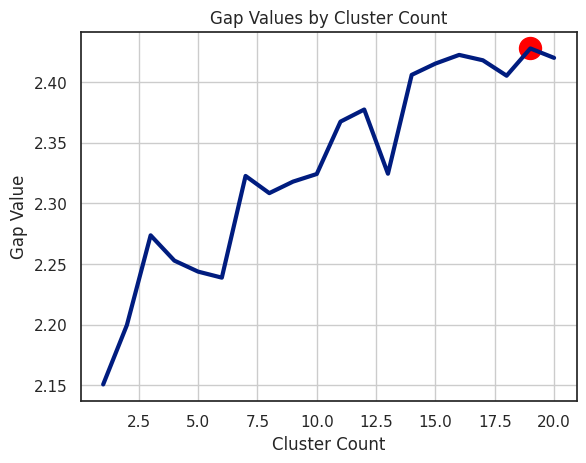

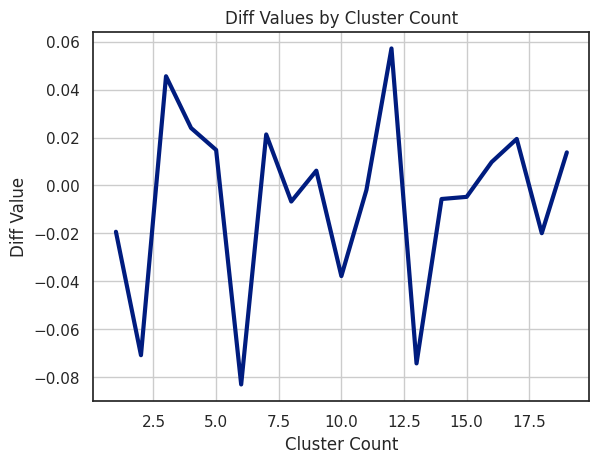

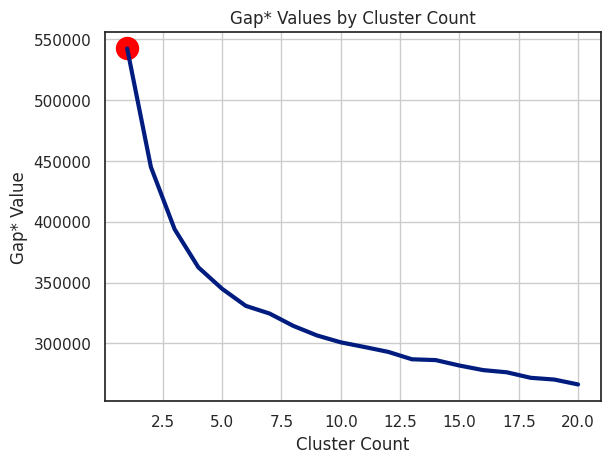

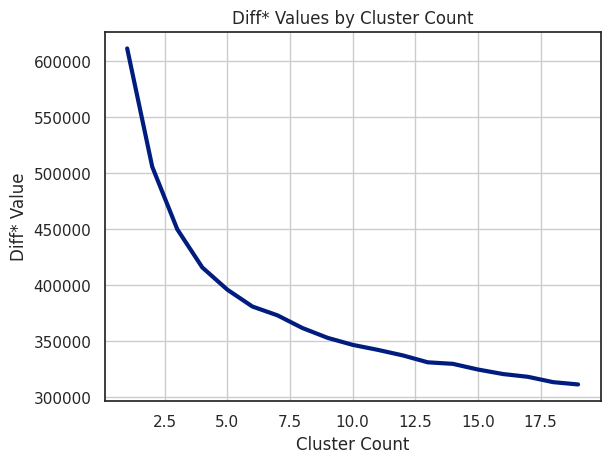

In [ ]:
optimalK.plot_results()

Though the cluster numbers are not necessarily identical, the clusters are very consistent within a single wine variety (red or white).

And here is a plot of the dendrogram created from agglomerative clustering.

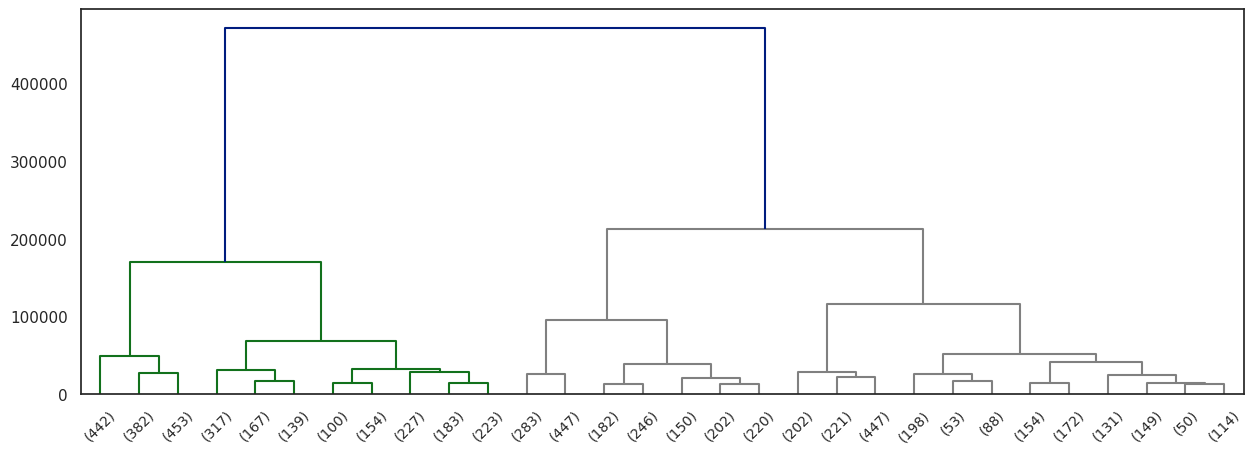

In [ ]:
from scipy.cluster import hierarchy
from matplotlib import colors

Z = hierarchy.linkage(ag.children_, method='ward')

fig, ax = plt.subplots(figsize=(15,5))

# Some color customization
dark_palette = sns.color_palette()
red = colors.to_hex(dark_palette[2])
blue = colors.to_hex(dark_palette[0])

hierarchy.set_link_color_palette([red, 'gray'])

den = hierarchy.dendrogram(Z, orientation='top',
                           p=30, truncate_mode='lastp',
                           show_leaf_counts=True, ax=ax,
                           above_threshold_color=blue)

## Question 6

In this question, we are going to explore clustering as a form of feature engineering.

* Create a **binary** target variable `y`, denoting if the quality is greater than 7 or not.
* Create a variable called `X_with_kmeans` from `data`, by dropping the columns "quality", "color" and "agglom" from the dataset. Create `X_without_kmeans` from that by dropping "kmeans".
* For both datasets, using `StratifiedShuffleSplit` with 10 splits, fit 10 Random Forest Classifiers and average out the roc-auc scores.
* Compare the average roc-auc scores for the models using the kmeans clusters as a feature and the one that doesn't use it.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit


y = (data['quality'] > 7).astype(int)
X_with_kmeans = data.drop(['agglom', 'color', 'quality'], axis=1)
X_without_kmeans = X_with_kmeans.drop('kmeans', axis=1)
sss = StratifiedShuffleSplit(n_splits=10, random_state=6532)


def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predicted = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
    return np.mean(roc_auc_list)
# return classification_report(y_test, y_predicted)


estimator = RandomForestClassifier()
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_kmeans, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_kmeans, y)
print("Without kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using kmeans cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))


Without kmeans cluster as input to Random Forest, roc-auc is "0.906638888888889"
Using kmeans cluster as input to Random Forest, roc-auc is "0.9035198412698413"


Let's now explore if the number of clusters have an effect in this improvement.

* Create the basis training set from `data` by restricting to float_columns.
* For $n = 1, \ldots, 20$, fit a kmeans algotihm with n clusters. One hot encode it and add it to the **basis** training set. Don't add it to the previous iteration.
* Fit 10 **Logistic Regression** models and compute the average roc-auc-score.
* Plot the average roc-auc scores.

<ipython-input-91-7128f03c85fb>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


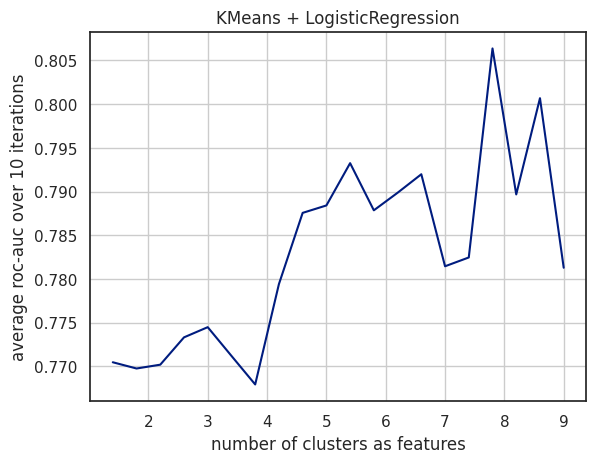

In [ ]:
from sklearn.linear_model import LogisticRegression

X_basis = data[float_columns]
sss = StratifiedShuffleSplit(n_splits=10, random_state=6532)


def create_kmeans_columns(n):
    km = KMeans(n_clusters=n)
    km.fit(X_basis)
    km_col = pd.Series(km.predict(X_basis))
    km_cols = pd.get_dummies(km_col, prefix='kmeans_cluster')
    return pd.concat([X_basis, km_cols], axis=1)


estimator = LogisticRegression()
ns = range(1, 21)
roc_auc_list = [get_avg_roc_10splits(estimator, create_kmeans_columns(n), y)
                for n in ns]


# seaborn styles
sns.set_context('notebook')
sns.set_style('white')
sns.set_palette('dark')

ax = plt.axes()
ax.plot(ns, roc_auc_list)
ax.set(
    xticklabels= ns,
    xlabel='number of clusters as features',
    ylabel='average roc-auc over 10 iterations',
    title='KMeans + LogisticRegression'
)
ax.grid(True)

#Conclusion:
This exercise teaches us the fundamentals of utilizing gap statistics, the Silhoutte method, and kmeans to determine the ideal k value. Since the Python file library for the optimalK doesn't run in the Colab notebook, we need to import it in order to troubleshoot the gap statistics, after calculating the inertia value. We can see that we have three different values for K, which indicates that different clustering strategies will provide different ideal values based on the amount of K we require and the proximity of each datapoint.